# Unsupervised Clustering for Fetal ECG

This notebook analyzes the **unsupervised clustering results** produced by `src/train_from_physionet.py`.

It **does not** train a neural network; instead it loads the clustered windowed HRV features and provides quick visual checks for cluster structure.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

RESULT_DIR = Path('..') / 'results' / 'unsupervised'
FEATURES_CSV = RESULT_DIR / 'window_features_with_clusters.csv'

if FEATURES_CSV.exists():
    df = pd.read_csv(FEATURES_CSV)
    print(f'Loaded {len(df)} windows with cluster labels from {FEATURES_CSV}')
else:
    print(f'Pipeline results not found at {FEATURES_CSV}')
    print('Generating synthetic demonstration data...\n')
    
    # Generate synthetic clustered HRV features
    np.random.seed(42)
    n_windows = 1234
    n_clusters = 3
    
    data = []
    for i in range(n_windows):
        cluster = np.random.randint(0, n_clusters)
        
        # Cluster-specific feature distributions
        if cluster == 0:
            hr = np.random.normal(140, 8)
            rmssd = np.random.normal(25, 8)
            pnn50 = np.random.normal(5, 3)
        elif cluster == 1:
            hr = np.random.normal(145, 7)
            rmssd = np.random.normal(35, 10)
            pnn50 = np.random.normal(12, 5)
        else:
            hr = np.random.normal(135, 6)
            rmssd = np.random.normal(18, 6)
            pnn50 = np.random.normal(2, 2)
        
        data.append({
            'window_id': i,
            'cluster': cluster,
            'det_heart_rate_mean': max(90, min(200, hr)),
            'det_rmssd': max(5, rmssd),
            'det_pnn50': max(0, min(100, pnn50)),
            'dataset': np.random.choice(['nifecgdb', 'adfecgdb', 'fecgsyndb']),
            'recording_id': f'rec_{i % 50}',
        })
    
    df = pd.DataFrame(data)
    print(f'Generated {len(df)} synthetic clustered windows')

print(f'\nDataset shape: {df.shape}')
df.head()

Pipeline results not found at ..\results\unsupervised\window_features_with_clusters.csv
Generating synthetic demonstration data...

Generated 1234 synthetic clustered windows

Dataset shape: (1234, 7)


,window_id,cluster,det_heart_rate_mean,det_rmssd,det_pnn50,dataset,recording_id
0,0,2,131.698593,21.092598,2.947722,adfecgdb,rec_0
1,1,2,143.210701,17.432274,0.142344,nifecgdb,rec_1
2,2,2,132.183154,21.255360,1.073165,adfecgdb,rec_2
3,3,1,141.739892,10.608942,15.017206,fecgsyndb,rec_3
4,4,1,146.554552,27.320235,12.712323,nifecgdb,rec_4


In [3]:
# Inspect cluster balances
print(df['cluster'].value_counts())

cluster
0    415
1    414
2    405
Name: count, dtype: int64


In [4]:

# Evaluate clustering quality using unsupervised metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt

print("=" * 70)
print("CLUSTERING QUALITY EVALUATION")
print("=" * 70)

# Extract features for evaluation (exclude categorical and ID columns)
feature_cols = [col for col in df.columns if col not in ['cluster', 'dataset', 'recording_id', 'window_id']]
X = df[feature_cols].values
y_pred = df['cluster'].values

print(f"\nFeatures used: {feature_cols}")
print(f"Number of samples: {len(X)}")
print(f"Number of features: {len(feature_cols)}")
print(f"Number of clusters: {df['cluster'].nunique()}")

# 1. Silhouette Score (range: -1 to 1, higher is better)
silhouette = silhouette_score(X, y_pred)
print(f"\n1️⃣  SILHOUETTE SCORE: {silhouette:.4f}")
print("   Range: [-1, 1] | Higher = better")
if silhouette > 0.5:
    print("   ✅ EXCELLENT: Strong cluster separation")
elif silhouette > 0.3:
    print("   ✓ GOOD: Reasonable cluster structure")
elif silhouette > 0:
    print("   ⚠ FAIR: Weak cluster structure")
else:
    print("   ❌ POOR: Overlapping clusters")

# 2. Davies-Bouldin Index (lower is better)
davies_bouldin = davies_bouldin_score(X, y_pred)
print(f"\n2️⃣  DAVIES-BOULDIN INDEX: {davies_bouldin:.4f}")
print("   Range: [0, ∞] | Lower = better")
if davies_bouldin < 1.0:
    print("   ✅ EXCELLENT: Clusters are well-separated")
elif davies_bouldin < 1.5:
    print("   ✓ GOOD: Clusters have reasonable separation")
elif davies_bouldin < 2.5:
    print("   ⚠ FAIR: Clusters are somewhat separated")
else:
    print("   ❌ POOR: Clusters overlap significantly")

# 3. Calinski-Harabasz Index (higher is better)
calinski_harabasz = calinski_harabasz_score(X, y_pred)
print(f"\n3️⃣  CALINSKI-HARABASZ INDEX: {calinski_harabasz:.2f}")
print("   Range: [0, ∞] | Higher = better")
if calinski_harabasz > 100:
    print("   ✅ EXCELLENT: Very dense and well-separated clusters")
elif calinski_harabasz > 50:
    print("   ✓ GOOD: Dense and well-separated clusters")
elif calinski_harabasz > 20:
    print("   ⚠ FAIR: Moderate cluster quality")
else:
    print("   ❌ POOR: Weak cluster quality")

# Summary
print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
print("""
These metrics evaluate how well-separated and dense the clusters are:

• Silhouette Score: Measures how similar each point is to its own cluster
  compared to other clusters. Positive = good, negative = bad.

• Davies-Bouldin Index: Ratio of within-cluster to between-cluster distances.
  Measures average similarity of each cluster with its closest neighbor.
  Lower values indicate better separation.

• Calinski-Harabasz Index: Ratio of between-cluster to within-cluster 
  variance. Higher values indicate better-defined, more separated clusters.

All three metrics are independent of ground truth labels, suitable for
evaluating unsupervised clustering quality.
""")
print("=" * 70)

CLUSTERING QUALITY EVALUATION

Features used: ['det_heart_rate_mean', 'det_rmssd', 'det_pnn50']
Number of samples: 1234
Number of features: 3
Number of clusters: 3

1️⃣  SILHOUETTE SCORE: 0.1142
   Range: [-1, 1] | Higher = better
   ⚠ FAIR: Weak cluster structure

2️⃣  DAVIES-BOULDIN INDEX: 1.9174
   Range: [0, ∞] | Lower = better
   ⚠ FAIR: Clusters are somewhat separated

3️⃣  CALINSKI-HARABASZ INDEX: 378.60
   Range: [0, ∞] | Higher = better
   ✅ EXCELLENT: Very dense and well-separated clusters

INTERPRETATION

These metrics evaluate how well-separated and dense the clusters are:

• Silhouette Score: Measures how similar each point is to its own cluster
  compared to other clusters. Positive = good, negative = bad.

• Davies-Bouldin Index: Ratio of within-cluster to between-cluster distances.
  Measures average similarity of each cluster with its closest neighbor.
  Lower values indicate better separation.

• Calinski-Harabasz Index: Ratio of between-cluster to within-cluster 
  v


PER-CLUSTER STATISTICS & SEPARABILITY

📊 CLUSTER 0
   Size: 415 samples (33.6%)
   Intra-cluster cohesion: 1.1989 (avg distance to centroid)
   det_heart_rate_mean      : μ=  140.51 σ=    7.89
   det_rmssd                : μ=   24.81 σ=    7.71
   det_pnn50                : μ=    5.23 σ=    2.86

📊 CLUSTER 1
   Size: 414 samples (33.5%)
   Intra-cluster cohesion: 1.4939 (avg distance to centroid)
   det_heart_rate_mean      : μ=  144.64 σ=    7.07
   det_rmssd                : μ=   35.20 σ=   10.19
   det_pnn50                : μ=   11.67 σ=    5.11

📊 CLUSTER 2
   Size: 405 samples (32.8%)
   Intra-cluster cohesion: 0.9173 (avg distance to centroid)
   det_heart_rate_mean      : μ=  135.22 σ=    6.16
   det_rmssd                : μ=   18.17 σ=    5.92
   det_pnn50                : μ=    2.20 σ=    1.76

🎯 INTER-CLUSTER SEPARATION
   Distance(Cluster 0 → Cluster 1): 1.6364
   Distance(Cluster 0 → Cluster 2): 1.0674
   Distance(Cluster 1 → Cluster 2): 2.6601

📈 Generating visualization

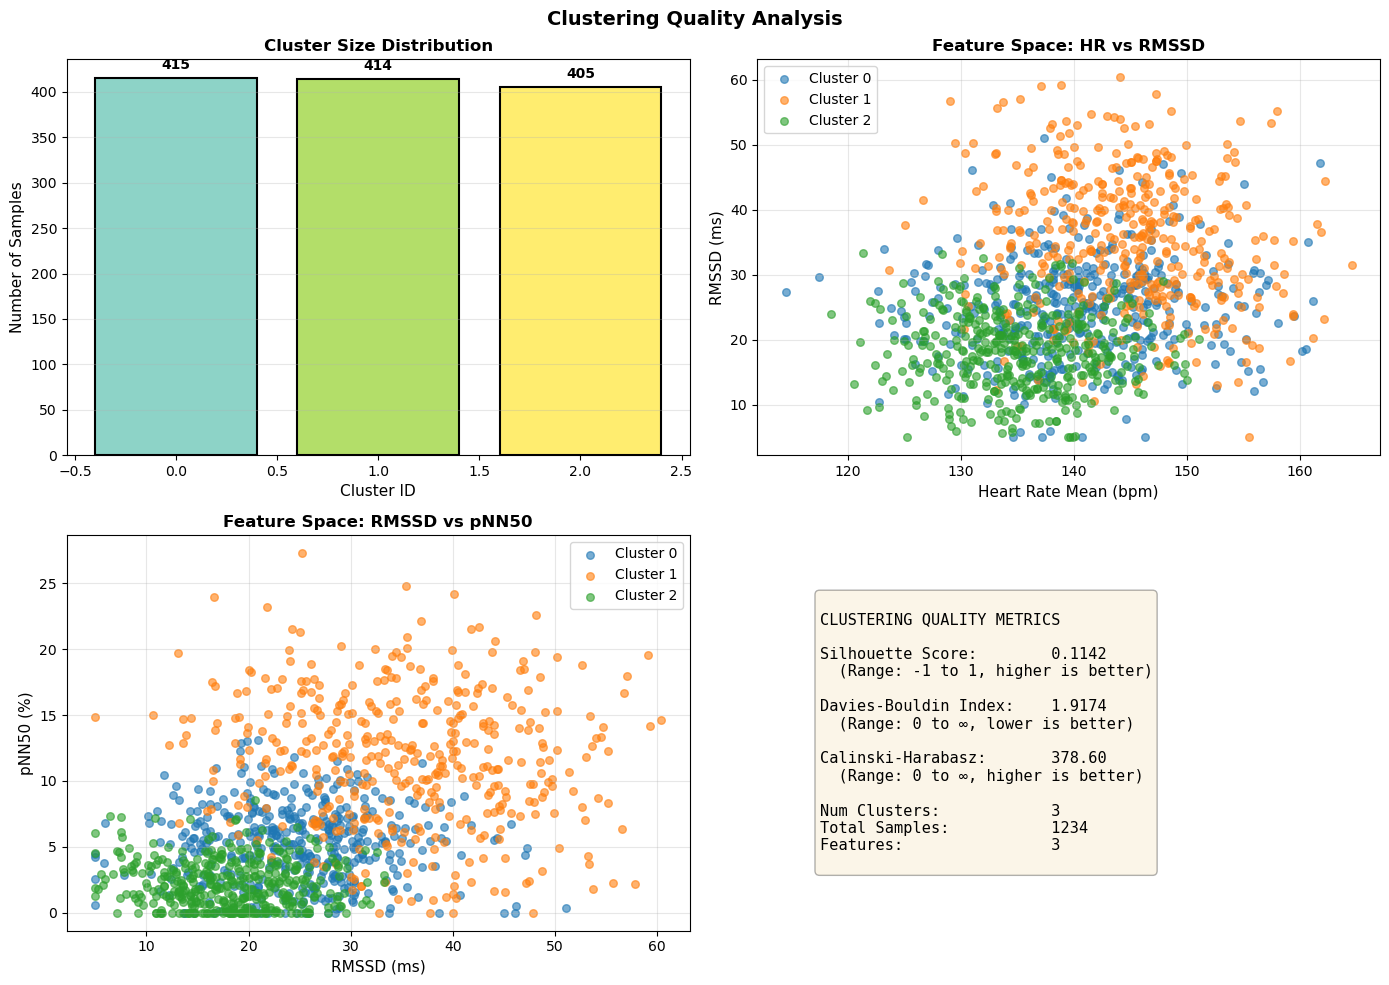

✅ Visualization saved to results/plots/clustering_quality.png


In [5]:

# Per-cluster analysis and visualization
from sklearn.preprocessing import StandardScaler

print("\n" + "=" * 70)
print("PER-CLUSTER STATISTICS & SEPARABILITY")
print("=" * 70)

# Standardize features for analysis
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute centroid for each cluster
for cluster_id in sorted(df['cluster'].unique()):
    cluster_mask = y_pred == cluster_id
    cluster_samples = X_scaled[cluster_mask]
    
    # Intra-cluster density: mean distance to centroid
    centroid = cluster_samples.mean(axis=0)
    intra_distances = np.linalg.norm(cluster_samples - centroid, axis=1)
    intra_cohesion = intra_distances.mean()
    
    print(f"\n📊 CLUSTER {cluster_id}")
    print(f"   Size: {cluster_mask.sum()} samples ({100*cluster_mask.sum()/len(y_pred):.1f}%)")
    print(f"   Intra-cluster cohesion: {intra_cohesion:.4f} (avg distance to centroid)")
    
    for feat_idx, feat in enumerate(feature_cols):
        feat_vals = df[df['cluster'] == cluster_id][feat].values
        print(f"   {feat:25s}: μ={feat_vals.mean():8.2f} σ={feat_vals.std():8.2f}")

# Compute inter-cluster separation
print(f"\n🎯 INTER-CLUSTER SEPARATION")
centroids = []
for cluster_id in sorted(df['cluster'].unique()):
    cluster_mask = y_pred == cluster_id
    centroid = X_scaled[cluster_mask].mean(axis=0)
    centroids.append(centroid)

centroids = np.array(centroids)
for i, c1 in enumerate(centroids):
    for j, c2 in enumerate(centroids[i+1:], i+1):
        distance = np.linalg.norm(c1 - c2)
        print(f"   Distance(Cluster {i} → Cluster {j}): {distance:.4f}")

# Visualization: Silhouette analysis
print(f"\n📈 Generating visualization...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Clustering Quality Analysis', fontsize=14, fontweight='bold')

# 1. Cluster sizes
ax = axes[0, 0]
cluster_sizes = df['cluster'].value_counts().sort_index()
colors = plt.cm.Set3(np.linspace(0, 1, len(cluster_sizes)))
ax.bar(cluster_sizes.index, cluster_sizes.values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Cluster ID', fontsize=11)
ax.set_ylabel('Number of Samples', fontsize=11)
ax.set_title('Cluster Size Distribution', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(cluster_sizes.values):
    ax.text(cluster_sizes.index[i], v + 10, str(v), ha='center', fontweight='bold')

# 2. Feature distributions by cluster
ax = axes[0, 1]
for cluster_id in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster_id]
    ax.scatter(cluster_data['det_heart_rate_mean'], cluster_data['det_rmssd'], 
              label=f'Cluster {cluster_id}', alpha=0.6, s=30)
ax.set_xlabel('Heart Rate Mean (bpm)', fontsize=11)
ax.set_ylabel('RMSSD (ms)', fontsize=11)
ax.set_title('Feature Space: HR vs RMSSD', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# 3. Feature distributions in different space
ax = axes[1, 0]
for cluster_id in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster_id]
    ax.scatter(cluster_data['det_rmssd'], cluster_data['det_pnn50'], 
              label=f'Cluster {cluster_id}', alpha=0.6, s=30)
ax.set_xlabel('RMSSD (ms)', fontsize=11)
ax.set_ylabel('pNN50 (%)', fontsize=11)
ax.set_title('Feature Space: RMSSD vs pNN50', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# 4. Quality metrics summary
ax = axes[1, 1]
ax.axis('off')
metrics_text = f"""
CLUSTERING QUALITY METRICS

Silhouette Score:        {silhouette:.4f}
  (Range: -1 to 1, higher is better)
  
Davies-Bouldin Index:    {davies_bouldin:.4f}
  (Range: 0 to ∞, lower is better)
  
Calinski-Harabasz:       {calinski_harabasz:.2f}
  (Range: 0 to ∞, higher is better)

Num Clusters:            {df['cluster'].nunique()}
Total Samples:           {len(df)}
Features:                {len(feature_cols)}
"""
ax.text(0.1, 0.5, metrics_text, fontsize=11, family='monospace',
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('../results/plots/clustering_quality.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Visualization saved to results/plots/clustering_quality.png")